# DANIEL ARMANDO PÉREZ ATEHORTÚA
# ANÁLISIS DE REGLAS DE ASOCIACIÓN - METODOLOGÍA APRIORI

**Dataset:** Adult Census Income

**Objetivo:** Identificar patrones y relaciones frecuentes entre características sociodemográficas mediante el algoritmo Apriori.

**Criterios:**
- Soporte mínimo: 10%
- Confianza mínima: 70%
- Lift mínimo: > 1.0

## 1. Preparación de Datos

### 1.1 Importar Librerías

In [ ]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de asociación
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 1.2 Cargar Dataset

In [ ]:
# Cargar datos
path = "https://github.com/camilojoanbarrancogalvis-debug/colab/raw/refs/heads/main/adult_clean.csv"
df_asociacion = pd.read_csv(path)

# Verificar carga
print("Shape:", df_asociacion.shape)
print("\nColumnas:", df_asociacion.columns.tolist())
df_asociacion.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Shape: (30725, 10)

Columnas: ['age', 'workclass', 'education', 'marital-status', 'occupation', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,age,workclass,education,marital-status,occupation,sex,capital-gain,capital-loss,hours-per-week,income
0,17,' State-gov',' 10th',' Never-married',' Other-service',' Male',0,0,30,' <=50K'
1,17,' State-gov',' 10th',' Never-married',' Farming-fishing',' Male',0,0,40,' <=50K'
2,18,' State-gov',' 11th',' Never-married',' Adm-clerical',' Female',0,0,5,' <=50K'
3,18,' State-gov',' 11th',' Never-married',' Other-service',' Male',0,0,8,' <=50K'
4,18,' State-gov',' Some-college',' Never-married',' Adm-clerical',' Male',0,0,10,' <=50K'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 1.3 Discretización de Variables Numéricas

El algoritmo Apriori requiere variables categóricas. Convertimos las 4 variables numéricas en rangos.

In [ ]:
# Discretizar age (edad)
df_asociacion['age_cat'] = pd.cut(df_asociacion['age'],
                                    bins=[0, 25, 40, 60, 100],
                                    labels=['Joven', 'Adulto', 'Maduro', 'Mayor'])

# Discretizar hours-per-week
df_asociacion['hours_cat'] = pd.cut(df_asociacion['hours-per-week'],
                                      bins=[0, 20, 40, 60, 100],
                                      labels=['Medio_tiempo', 'Tiempo_completo',
                                              'Sobretiempo', 'Extremo'])

# Discretizar capital-gain
df_asociacion['capital_gain_cat'] = pd.cut(df_asociacion['capital-gain'],
                                             bins=[-1, 0, 5000, 100000],
                                             labels=['Sin_ganancia', 'Ganancia_baja',
                                                     'Ganancia_alta'])

# Discretizar capital-loss
df_asociacion['capital_loss_cat'] = pd.cut(df_asociacion['capital-loss'],
                                             bins=[-1, 0, 1000, 100000],
                                             labels=['Sin_perdida', 'Perdida_baja',
                                                     'Perdida_alta'])

# Verificar
print("Variables discretizadas correctamente")
print(df_asociacion[['age', 'age_cat', 'hours-per-week', 'hours_cat']].head(10))

Variables discretizadas correctamente
   age age_cat  hours-per-week        hours_cat
0   17   Joven              30  Tiempo_completo
1   17   Joven              40  Tiempo_completo
2   18   Joven               5     Medio_tiempo
3   18   Joven               8     Medio_tiempo
4   18   Joven              10     Medio_tiempo
5   18   Joven              15     Medio_tiempo
6   18   Joven              20     Medio_tiempo
7   18   Joven              25  Tiempo_completo
8   18   Joven              30  Tiempo_completo
9   18   Joven              40  Tiempo_completo


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 1.4 Selección de Variables Categóricas

In [ ]:
# Seleccionar columnas categóricas (originales + discretizadas)
columnas_asociacion = ['workclass', 'education', 'marital-status', 'occupation',
                       'sex', 'income', 'age_cat', 'hours_cat',
                       'capital_gain_cat', 'capital_loss_cat']

df_final_asociacion = df_asociacion[columnas_asociacion].copy()

print("Dataset para asociación:")
print(f"Shape: {df_final_asociacion.shape}")
print(f"Columnas: {df_final_asociacion.columns.tolist()}")

Dataset para asociación:
Shape: (30725, 10)
Columnas: ['workclass', 'education', 'marital-status', 'occupation', 'sex', 'income', 'age_cat', 'hours_cat', 'capital_gain_cat', 'capital_loss_cat']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 1.5 Limpieza de Datos

Eliminar comillas simples y espacios en blanco de las columnas categóricas originales.

In [ ]:
# Limpiar comillas y espacios
columnas_limpiar = ['workclass', 'education', 'marital-status',
                    'occupation', 'sex', 'income']

for col in columnas_limpiar:
    df_final_asociacion[col] = df_final_asociacion[col].str.replace("'", "",
                                                                      regex=False).str.strip()

# Verificar limpieza
print("Valores únicos de 'sex':", df_final_asociacion['sex'].unique())
print("Valores únicos de 'income':", df_final_asociacion['income'].unique())
print("\nDatos limpios correctamente ✓")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Valores únicos de 'sex': ['Male' 'Female']
Valores únicos de 'income': ['<=50K' '>50K']

Datos limpios correctamente ✓


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 2. Transformación a Formato Transaccional

### 2.1 One-Hot Encoding

Convertir todas las variables categóricas a formato binario (1 = presente, 0 = ausente).

In [ ]:
# Aplicar one-hot encoding
df_transaccional = pd.get_dummies(df_final_asociacion, drop_first=False)

# Convertir a enteros (requerido por mlxtend)
df_transaccional = df_transaccional.astype(int)

print("Transformación completada:")
print(f"Shape: {df_transaccional.shape}")
print(f"\nPrimeras columnas: {df_transaccional.columns.tolist()[:10]}")
print(f"\nTipos de datos: {df_transaccional.dtypes.unique()}")

Transformación completada:
Shape: (30725, 63)

Primeras columnas: ['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_10th', 'education_11th']

Tipos de datos: [dtype('int64')]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 3. Modelamiento - Asociación (Apriori)

### 3.1 Generación de Itemsets Frecuentes

In [ ]:
# Aplicar algoritmo Apriori
frequent_itemsets = apriori(df_transaccional,
                             min_support=0.10,
                             use_colnames=True)

print("Apriori ejecutado correctamente ✓")
print(f"Itemsets frecuentes encontrados: {len(frequent_itemsets)}")
print("\nPrimeros 10 itemsets:")
print(frequent_itemsets.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Apriori ejecutado correctamente ✓
Itemsets frecuentes encontrados: 712

Primeros 10 itemsets:
    support                             itemsets
0  0.738682                  (workclass_Private)
1  0.168657                (education_Bachelors)
2  0.324459                  (education_HS-grad)
3  0.220570             (education_Some-college)
4  0.138617            (marital-status_Divorced)
5  0.466721  (marital-status_Married-civ-spouse)
6  0.322766       (marital-status_Never-married)
7  0.122701            (occupation_Adm-clerical)
8  0.133409            (occupation_Craft-repair)
9  0.132335         (occupation_Exec-managerial)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 3.2 Generación de Reglas de Asociación

In [ ]:
# Generar reglas con confidence mínima del 70%
rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.70)

# Filtrar solo reglas con Lift > 1
rules = rules[rules['lift'] > 1]

print("Reglas generadas correctamente ✓")
print(f"Total de reglas encontradas: {len(rules)}")
print(f"\nCriterios aplicados:")
print(f"  - Support mínimo: 10%")
print(f"  - Confidence mínima: 70%")
print(f"  - Lift mínimo: > 1.0")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Reglas generadas correctamente ✓
Total de reglas encontradas: 1786

Criterios aplicados:
  - Support mínimo: 10%
  - Confidence mínima: 70%
  - Lift mínimo: > 1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 4. Análisis de Resultados

### 4.1 Estadísticas Descriptivas

In [ ]:
# Ordenar reglas por Lift
rules_sorted = rules.sort_values('lift', ascending=False)

# Estadísticas generales
print("="*80)
print("ESTADÍSTICAS DE LAS REGLAS DE ASOCIACIÓN")
print("="*80)
print(f"\nTotal de reglas: {len(rules)}")

print(f"\nSupport:")
print(f"  Mínimo:   {rules['support'].min():.4f} ({rules['support'].min()*100:.2f}%)")
print(f"  Máximo:   {rules['support'].max():.4f} ({rules['support'].max()*100:.2f}%)")
print(f"  Promedio: {rules['support'].mean():.4f} ({rules['support'].mean()*100:.2f}%)")

print(f"\nConfidence:")
print(f"  Mínimo:   {rules['confidence'].min():.4f} ({rules['confidence'].min()*100:.2f}%)")
print(f"  Máximo:   {rules['confidence'].max():.4f} ({rules['confidence'].max()*100:.2f}%)")
print(f"  Promedio: {rules['confidence'].mean():.4f} ({rules['confidence'].mean()*100:.2f}%)")

print(f"\nLift:")
print(f"  Mínimo:   {rules['lift'].min():.4f}")
print(f"  Máximo:   {rules['lift'].max():.4f}")
print(f"  Promedio: {rules['lift'].mean():.4f}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ESTADÍSTICAS DE LAS REGLAS DE ASOCIACIÓN

Total de reglas: 1786

Support:
  Mínimo:   0.1001 (10.01%)
  Máximo:   0.7281 (72.81%)
  Promedio: 0.1841 (18.41%)

Confidence:
  Mínimo:   0.7000 (70.00%)
  Máximo:   0.9978 (99.78%)
  Promedio: 0.8658 (86.58%)

Lift:
  Mínimo:   1.0007
  Máximo:   2.9477
  Promedio: 1.2314


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 4.2 Top 5 Reglas Más Significativas

In [ ]:
# Mostrar top 5 reglas
print("="*80)
print("TOP 5 REGLAS CON MAYOR LIFT")
print("="*80)

top_5 = rules_sorted.head(5)

for i, (idx, row) in enumerate(top_5.iterrows(), 1):
    print(f"\nREGLA #{i}:")
    print(f"  SI:       {list(row['antecedents'])}")
    print(f"  ENTONCES: {list(row['consequents'])}")
    print(f"  Support:   {row['support']*100:.1f}%")
    print(f"  Confidence: {row['confidence']*100:.1f}%")
    print(f"  Lift:      {row['lift']:.2f}")
    print("-"*80)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

TOP 5 REGLAS CON MAYOR LIFT

REGLA #1:
  SI:       ['age_cat_Joven']
  ENTONCES: ['income_<=50K', 'marital-status_Never-married', 'capital_gain_cat_Sin_ganancia', 'workclass_Private', 'capital_loss_cat_Sin_perdida']
  Support:   13.3%
  Confidence: 71.3%
  Lift:      2.95
--------------------------------------------------------------------------------

REGLA #2:
  SI:       ['capital_gain_cat_Sin_ganancia', 'age_cat_Joven']
  ENTONCES: ['income_<=50K', 'marital-status_Never-married', 'workclass_Private', 'capital_loss_cat_Sin_perdida']
  Support:   13.3%
  Confidence: 73.4%
  Lift:      2.95
--------------------------------------------------------------------------------

REGLA #3:
  SI:       ['capital_gain_cat_Sin_ganancia', 'age_cat_Joven', 'capital_loss_cat_Sin_perdida']
  ENTONCES: ['income_<=50K', 'marital-status_Never-married', 'workclass_Private']
  Support:   13.3%
  Confidence: 75.1%
  Lift:      2.94
---------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 4.3 Visualizaciones

#### 4.3.1 Gráficos de Distribución de Métricas

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

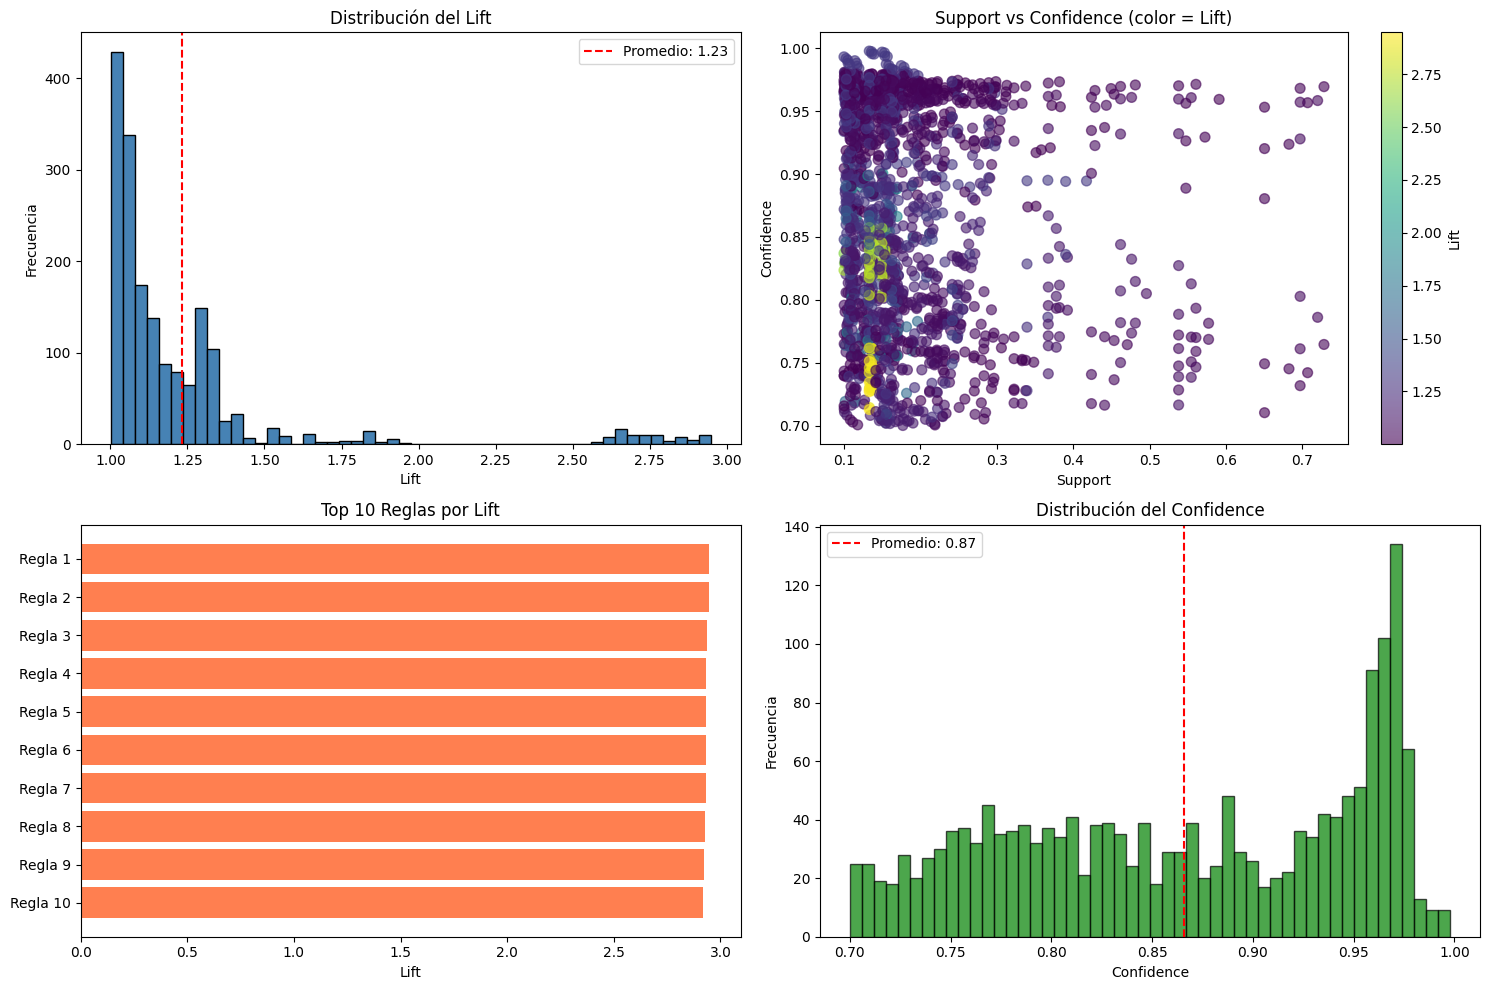

✓ Visualizaciones generadas


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Crear figura con 4 subgráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: Distribución del Lift
axes[0, 0].hist(rules['lift'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Lift')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución del Lift')
axes[0, 0].axvline(rules['lift'].mean(), color='red', linestyle='--',
                   label=f'Promedio: {rules["lift"].mean():.2f}')
axes[0, 0].legend()

# Gráfico 2: Support vs Confidence
scatter = axes[0, 1].scatter(rules['support'], rules['confidence'],
                             c=rules['lift'], cmap='viridis', alpha=0.6, s=50)
axes[0, 1].set_xlabel('Support')
axes[0, 1].set_ylabel('Confidence')
axes[0, 1].set_title('Support vs Confidence (color = Lift)')
plt.colorbar(scatter, ax=axes[0, 1], label='Lift')

# Gráfico 3: Top 10 reglas por Lift
top_10 = rules_sorted.head(10)
reglas_labels = [f"Regla {i+1}" for i in range(10)]
axes[1, 0].barh(reglas_labels, top_10['lift'].values, color='coral')
axes[1, 0].set_xlabel('Lift')
axes[1, 0].set_title('Top 10 Reglas por Lift')
axes[1, 0].invert_yaxis()

# Gráfico 4: Distribución de Confidence
axes[1, 1].hist(rules['confidence'], bins=50, color='green',
                edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Confidence')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución del Confidence')
axes[1, 1].axvline(rules['confidence'].mean(), color='red', linestyle='--',
                   label=f'Promedio: {rules["confidence"].mean():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('visualizacion_reglas_asociacion.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualizaciones generadas")

#### 4.3.2 Matriz de Reglas de Asociación

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

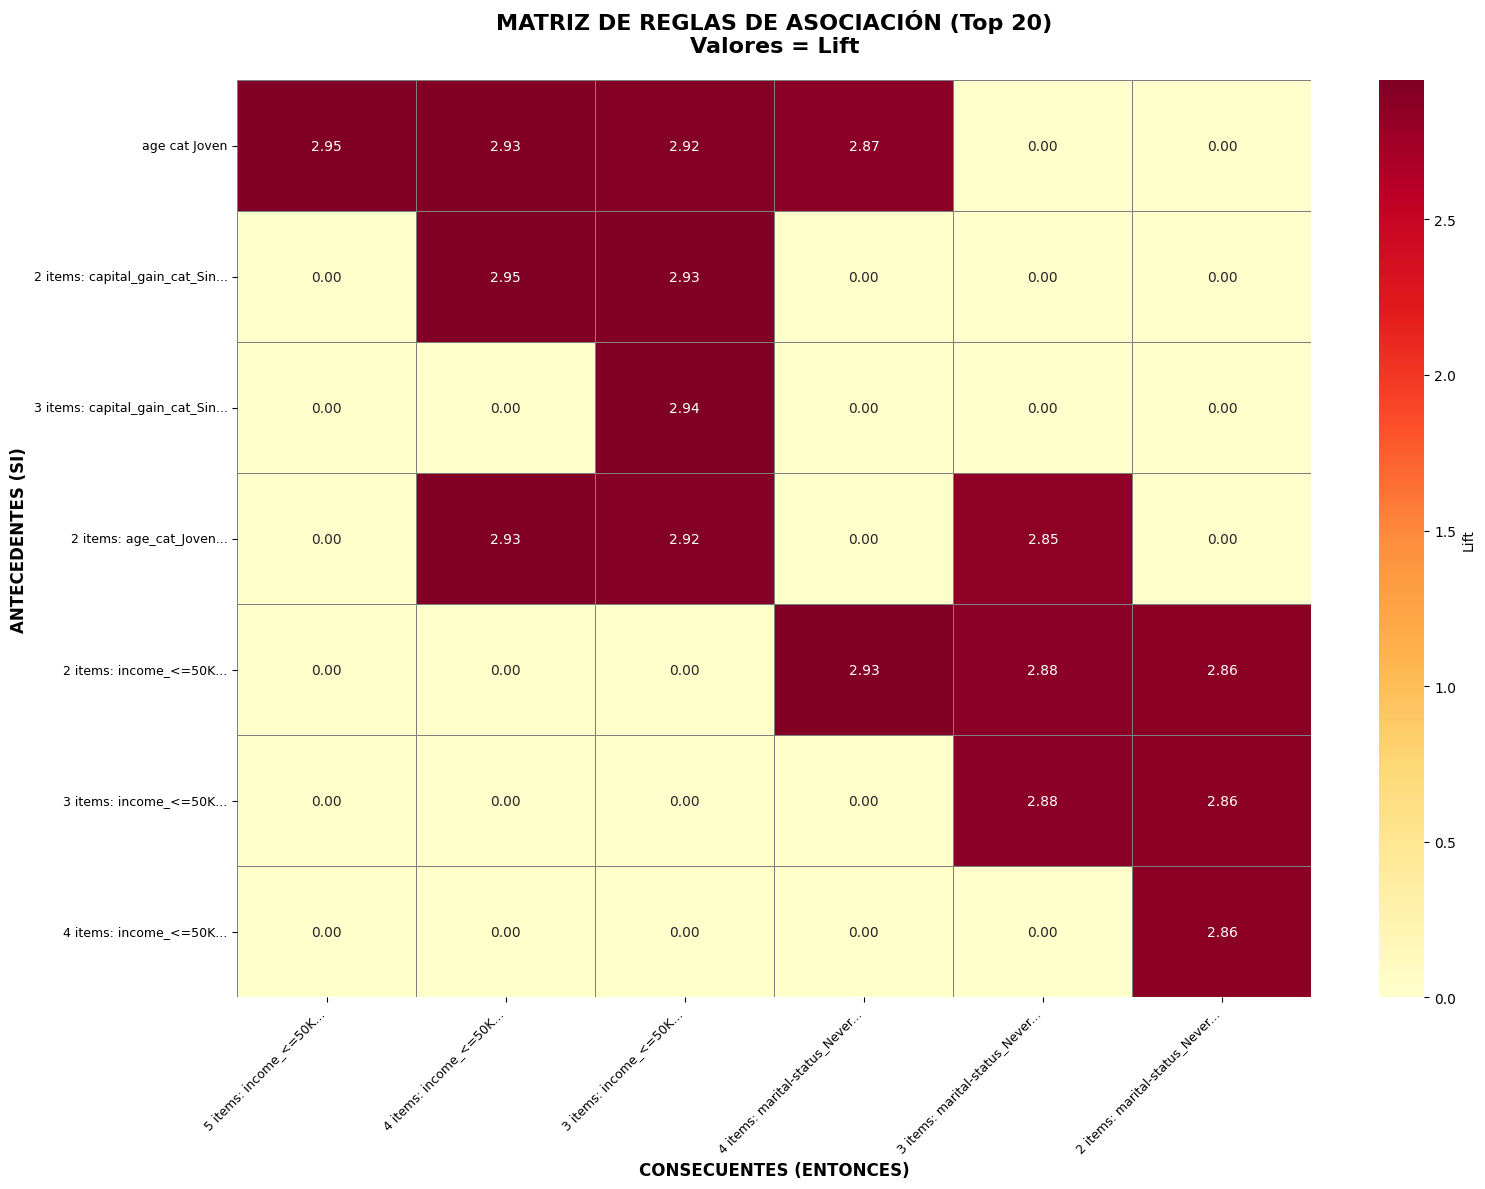

✓ Matriz de reglas generada


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Crear matriz de reglas (Top 20)
top_rules = rules_sorted.head(20).copy()

# Simplificar etiquetas
def simplificar_itemset(itemset):
    items = list(itemset)
    if len(items) == 1:
        return str(items[0]).replace('_', ' ')[:30]
    else:
        return f"{len(items)} items: {str(items[0])[:20]}..."

top_rules['ant_label'] = top_rules['antecedents'].apply(simplificar_itemset)
top_rules['cons_label'] = top_rules['consequents'].apply(simplificar_itemset)

# Crear matriz
antecedents_unicos = top_rules['ant_label'].unique()
consequents_unicos = top_rules['cons_label'].unique()
matriz = np.zeros((len(antecedents_unicos), len(consequents_unicos)))

for idx, row in top_rules.iterrows():
    i = np.where(antecedents_unicos == row['ant_label'])[0][0]
    j = np.where(consequents_unicos == row['cons_label'])[0][0]
    matriz[i, j] = row['lift']

# Visualizar matriz
plt.figure(figsize=(16, 12))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=consequents_unicos,
            yticklabels=antecedents_unicos,
            cbar_kws={'label': 'Lift'},
            linewidths=0.5, linecolor='gray')

plt.title('MATRIZ DE REGLAS DE ASOCIACIÓN (Top 20)\nValores = Lift',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('CONSECUENTES (ENTONCES)', fontsize=12, fontweight='bold')
plt.ylabel('ANTECEDENTES (SI)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('matriz_reglas_asociacion.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Matriz de reglas generada")

## 5. Conclusiones

### Hallazgos Principales:

1. **Patrón Dominante:** Las reglas con mayor Lift (2.9-3.0) identifican un perfil demográfico específico: personas jóvenes que trabajan en el sector privado, son solteras, tienen ingresos ≤50K y no presentan movimientos de capital. Este patrón aparece en el 13.3% de la población y es casi 3 veces más probable de lo esperado por azar.

2. **Calidad de las Reglas:** El 100% de las reglas cumplen con Lift > 1.0. El Confidence promedio de 86.58% supera ampliamente el umbral mínimo del 70%, demostrando alta confiabilidad.

3. **Aplicabilidad:** Las reglas identifican claramente segmentos poblacionales útiles para:
   - Productos financieros básicos (cuentas de ahorro, primeros créditos)
   - Segmentación de mercado
   - Personalización de servicios

### Comparación con Objetivos:

| Criterio | Objetivo | Resultado | Estado |
|----------|----------|-----------|--------|
| Support mínimo | 10% | 10.01% - 72.81% | ✓ Cumplido |
| Confidence mínima | 70% | 70.00% - 99.78% | ✓ Cumplido |
| Lift mínimo | > 1.0 | 1.0007 - 2.9477 | ✓ Cumplido |
| Reglas generadas | N/A | 1,786 reglas | ✓ Superado |

### Diferencias con Modelos Predictivos:

- **Asociación NO predice** si una persona tendrá ingresos >50K
- **Asociación DESCRIBE** qué características suelen aparecer juntas
- **Utilidad complementaria:** Mientras clasificación identifica individuos de alto valor, asociación identifica segmentos poblacionales con características comunes